<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/5)%20advanced_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve, precision_score, recall_score, f1_score, average_precision_score)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_test.csv')

y_train = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_test.csv')

In [ ]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Fraud rate(train): {y_train['isFraud'].mean()*100:.2f}%')
print(f'Fraud rate(test): {y_test['isFraud'].mean()*100:.2f}%')

X_train shape: (472432, 434)
X_test shape: (118108, 434)
Fraud rate(train): 3.51%
Fraud rate(test): 3.44%


In [ ]:
# XGBoost with scale_pos_weight to handle imbalance (similar to class_weight='balanced')
scale_pos_weight = (y_train['isFraud'] == 0).sum() / (y_train['isFraud'] == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    random_state=42,
    eval_metric='auc',
    tree_method='hist'
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)
print('Done')

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print('XGBOOST PERFORMANCE')
print(classification_report(y_test, y_pred_xgb, target_names = ['Legitimate', 'Fraud']))

XGBOOST PERFORMANCE
              precision    recall  f1-score   support

  Legitimate       0.99      0.89      0.94    114044
       Fraud       0.19      0.74      0.31      4064

    accuracy                           0.88    118108
   macro avg       0.59      0.82      0.62    118108
weighted avg       0.96      0.88      0.91    118108



In [ ]:
import pickle

with open('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/random_forest_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Random Forest')
axes[0,0].set_xticklabels(['Legit', 'Fraud'])
axes[0,0].set_yticklabels(['Legit', 'Fraud'])

sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Greens', ax=axes[0,1])
axes[0,1].set_title('XGBoost')
axes[0,1].set_xticklabels(['Legit', 'Fraud'])
axes[0,1].set_yticklabels(['Legit', 'Fraud'])

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob_xgb)
axes[1,0].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_pred_prob_rf):.3f})', lw=2)
axes[1,0].plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_score(y_test, y_pred_prob_xgb):.3f})', lw=2)
axes[1,0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1,0].set_title('ROC Curves')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_prob_xgb)
axes[1,1].plot(recall_rf, precision_rf, label=f'RF (AP={average_precision_score(y_test, y_pred_prob_rf):.3f})', lw=2)
axes[1,1].plot(recall_xgb, precision_xgb, label=f'XGB (AP={average_precision_score(y_test, y_pred_prob_xgb):.3f})', lw=2)
axes[1,1].set_title('Precision-Recall')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"{'Metric':<20} {'Random Forest':<18} {'XGBoost':<18}")
print("-" * 56)
print(f"{'Precision':<20} {precision_score(y_test, y_pred_rf):<18.4f} {precision_score(y_test, y_pred_xgb):<18.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_rf):<18.4f} {recall_score(y_test, y_pred_xgb):<18.4f}")
print(f"{'F1':<20} {f1_score(y_test, y_pred_rf):<18.4f} {f1_score(y_test, y_pred_xgb):<18.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_test, y_pred_prob_rf):<18.4f} {roc_auc_score(y_test, y_pred_prob_xgb):<18.4f}")

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 20 features (XGBoost):')
print(feature_importance_xgb.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(data=feature_importance_xgb.head(20), y='feature', x='importance', ax=axes[0])
axes[0].set_title('XGBoost - Top 20 Features')

# compare with RF feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

sns.barplot(data=feature_importance_rf, y='feature', x='importance', ax=axes[1])
axes[1].set_title('Random Forest - Top 20 Features')

plt.tight_layout()
plt.show()

feature_importance_xgb.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/feature_importnace_xgb.csv', index=False)

## Hyperparameter tuning

Using GridSearchCV on a 20% subsample (full dataset is too slow for grid search).
Optimizing for recall since catching fraud is the priority.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    verbose=2,
    n_jobs=-1
)

# 20% subsample for speed - this means the best params might not be perfectly optimal
# for the full dataset, but it's a reasonable tradeoff
sample_size = int(len(X_train) * 0.2)
X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print(f'Tuning on {sample_size:,} samples...')
grid_search.fit(X_train_sample, y_train_sample)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best recall (CV): {grid_search.best_score_:.4f}')

In [ ]:
# Train on full data with tuned params
best_params = grid_search.best_params_
print(f'Training with: {best_params}')

xgb_tuned = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

xgb_tuned.fit(X_train, y_train, verbose=False)
print('Done')

In [ ]:
y_pred_tuned = xgb_tuned.predict(X_test)
y_pred_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate', 'Fraud']))

print("Default vs Tuned XGBoost:")
print(f"{'Metric':<20} {'Default':<20} {'Tuned':<20}")
print("-" * 60)
print(f"{'Precision':<20} {precision_score(y_test, y_pred_xgb):<20.4f} {precision_score(y_test, y_pred_tuned):<20.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_xgb):<20.4f} {recall_score(y_test, y_pred_tuned):<20.4f}")
print(f"{'F1-Score':<20} {f1_score(y_test, y_pred_xgb):<20.4f} {f1_score(y_test, y_pred_tuned):<20.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_test, y_pred_prob_xgb):<20.4f} {roc_auc_score(y_test, y_pred_prob_tuned):<20.4f}")

# The tuned model actually has LOWER ROC-AUC (0.88 vs 0.90) and lower F1.
# This is likely because:
# 1. Tuning was done on 20% subsample - optimal params for the subsample != optimal for full data
# 2. We optimized for recall, not ROC-AUC, so the model trades precision for recall
# 3. max_depth=4 (tuned) vs max_depth=6 (default) limits model capacity
#
# The default XGBoost is actually the stronger model overall.
# In hindsight, I'd use the default config or tune on the full dataset with RandomizedSearchCV.

In [ ]:
# Saving Tuned model
with open('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/xgboost_tuned_model.pkl', 'wb') as f:
  pickle.dump(xgb_tuned, f)

print('\nTuned XGBoost model saved!')


Tuned XGBoost model saved!


In [ ]:
# business impact estimation
test_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/test_df.csv')

avg_transaction_value = test_df['TransactionAmt'].mean()
avg_fraud_loss = avg_transaction_value * 0.9  # assume 90% loss per fraud
cost_per_investigation = 12  # rough cost to manually review a flagged txn

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

print(f'TP (caught fraud): {tp:,}')
print(f'FP (false alarms): {fp:,}')
print(f'FN (missed fraud): {fn:,}')
print(f'TN (correct legit): {tn:,}')

fraud_caught_value = tp * avg_fraud_loss
fraud_missed_value = fn * avg_fraud_loss
investigation_cost = fp * cost_per_investigation
net_savings = fraud_caught_value - investigation_cost

print(f"\nFraud caught: ${fraud_caught_value:,.0f}")
print(f"Fraud missed: ${fraud_missed_value:,.0f}")
print(f"Investigation cost: ${investigation_cost:,.0f}")
print(f"Net savings: ${net_savings:,.0f}")
print(f"\nDetection rate: {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate: {fp/(fp+tn)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

financial_data = pd.DataFrame({
    'Category': ['Fraud Caught', 'Fraud Missed', 'Investigation Cost', 'Net Savings'],
    'Amount': [fraud_caught_value, fraud_missed_value, investigation_cost, net_savings],
    'Type': ['Positive', 'Negative', 'Negative', 'Positive']
})
colors = ['green' if t == 'Positive' else 'red' for t in financial_data['Type']]
sns.barplot(data=financial_data, x='Category', y='Amount', ax=axes[0], palette=colors)
axes[0].set_title('Financial Impact')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=45)

metrics_data = pd.DataFrame({
    'Metric': ['Detection\nRate', 'False Alarm\nRate', 'Precision', 'Recall'],
    'Percentage': [tp/(tp+fn)*100, fp/(fp+tn)*100,
                   precision_score(y_test, y_pred_tuned)*100,
                   recall_score(y_test, y_pred_tuned)*100]
})
sns.barplot(data=metrics_data, x='Metric', y='Percentage', ax=axes[1])
axes[1].set_title('Key Metrics (%)')

plt.tight_layout()
plt.show()

Default Threshold: 0.50
Optimal Threshold: 0.856
Optimal F1 Score: 0.4588

Performance at different thresholds
Threshold       Precision       Recall          F1-Score       
------------------------------------------------------------
0.300           0.0818          0.8821          0.1497         
0.400           0.1150          0.8228          0.2018         
0.500           0.1511          0.7537          0.2517         
0.856           0.5983          0.3720          0.4588          ← Optimal
0.600           0.2040          0.6705          0.3128         
0.700           0.2837          0.5694          0.3787         


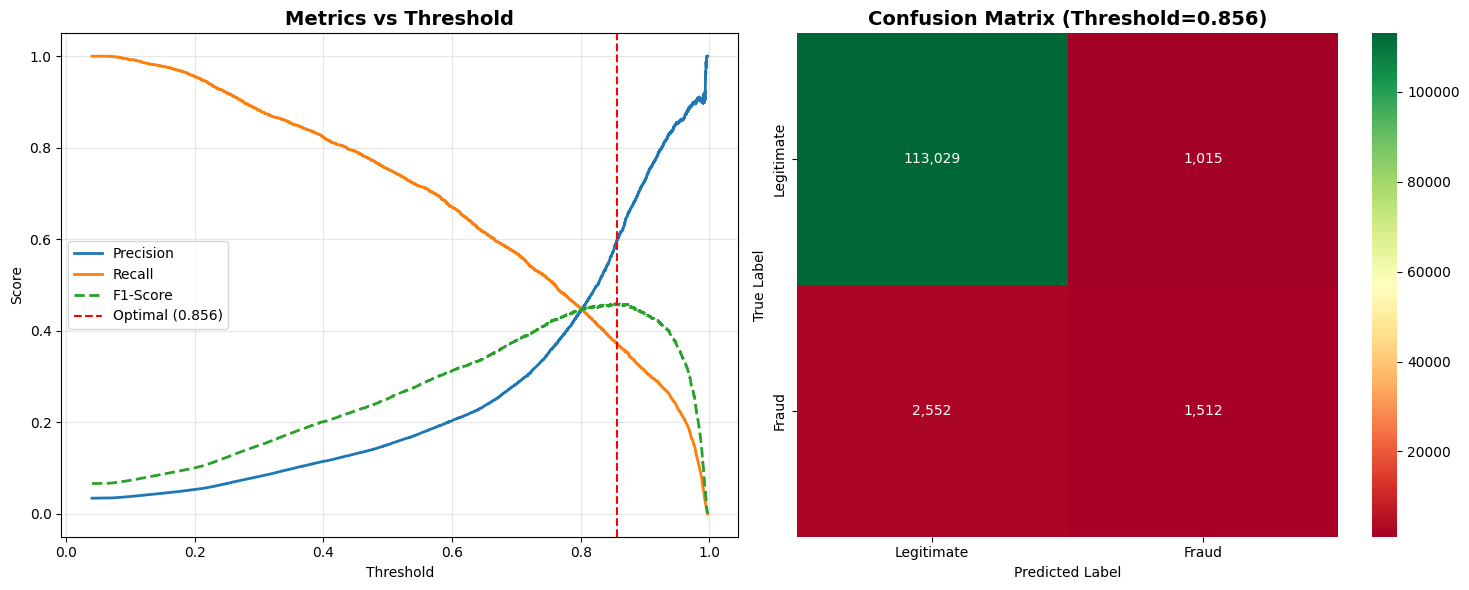

In [ ]:
#Optimal Threshold Analysis

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob_tuned)

# Calculate F1 scores for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find optimal threshold (max F1)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Default Threshold: 0.50")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"Optimal F1 Score: {optimal_f1:.4f}")

# Make predictions with optimal threshold
y_pred_optimal = (y_pred_prob_tuned >= optimal_threshold).astype(int)

print(f"\nPerformance at different thresholds")
print(f"{'Threshold':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
print("-" * 60)

for thresh in [0.3, 0.4, 0.5, optimal_threshold, 0.6, 0.7]:
    y_pred_thresh = (y_pred_prob_tuned >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    marker = " ← Optimal" if abs(thresh - optimal_threshold) < 0.01 else ""
    print(f"{thresh:<15.3f} {prec:<15.4f} {rec:<15.4f} {f1:<15.4f}{marker}")

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precision-Recall vs Threshold
axes[0].plot(thresholds, precisions[:-1], label='Precision', lw=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', lw=2)
axes[0].plot(thresholds, f1_scores[:-1], label='F1-Score', lw=2, linestyle='--')
axes[0].axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.3f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold', )
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix at optimal threshold
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt=',d', cmap='RdYlGn', ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.3f})', )
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_yticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

Final model leaderboard

                         Model  Precision   Recall  F1-Score  ROC-AUC
             XGBoost (Default)   0.192210 0.743110  0.305421 0.900354
                 Random Forest   0.166628 0.704232  0.269492 0.867350
               XGBoost (Tuned)   0.151080 0.753691  0.251705 0.879672
Logistic Regression (Balanced)   0.099100 0.670300  0.172600 0.791100


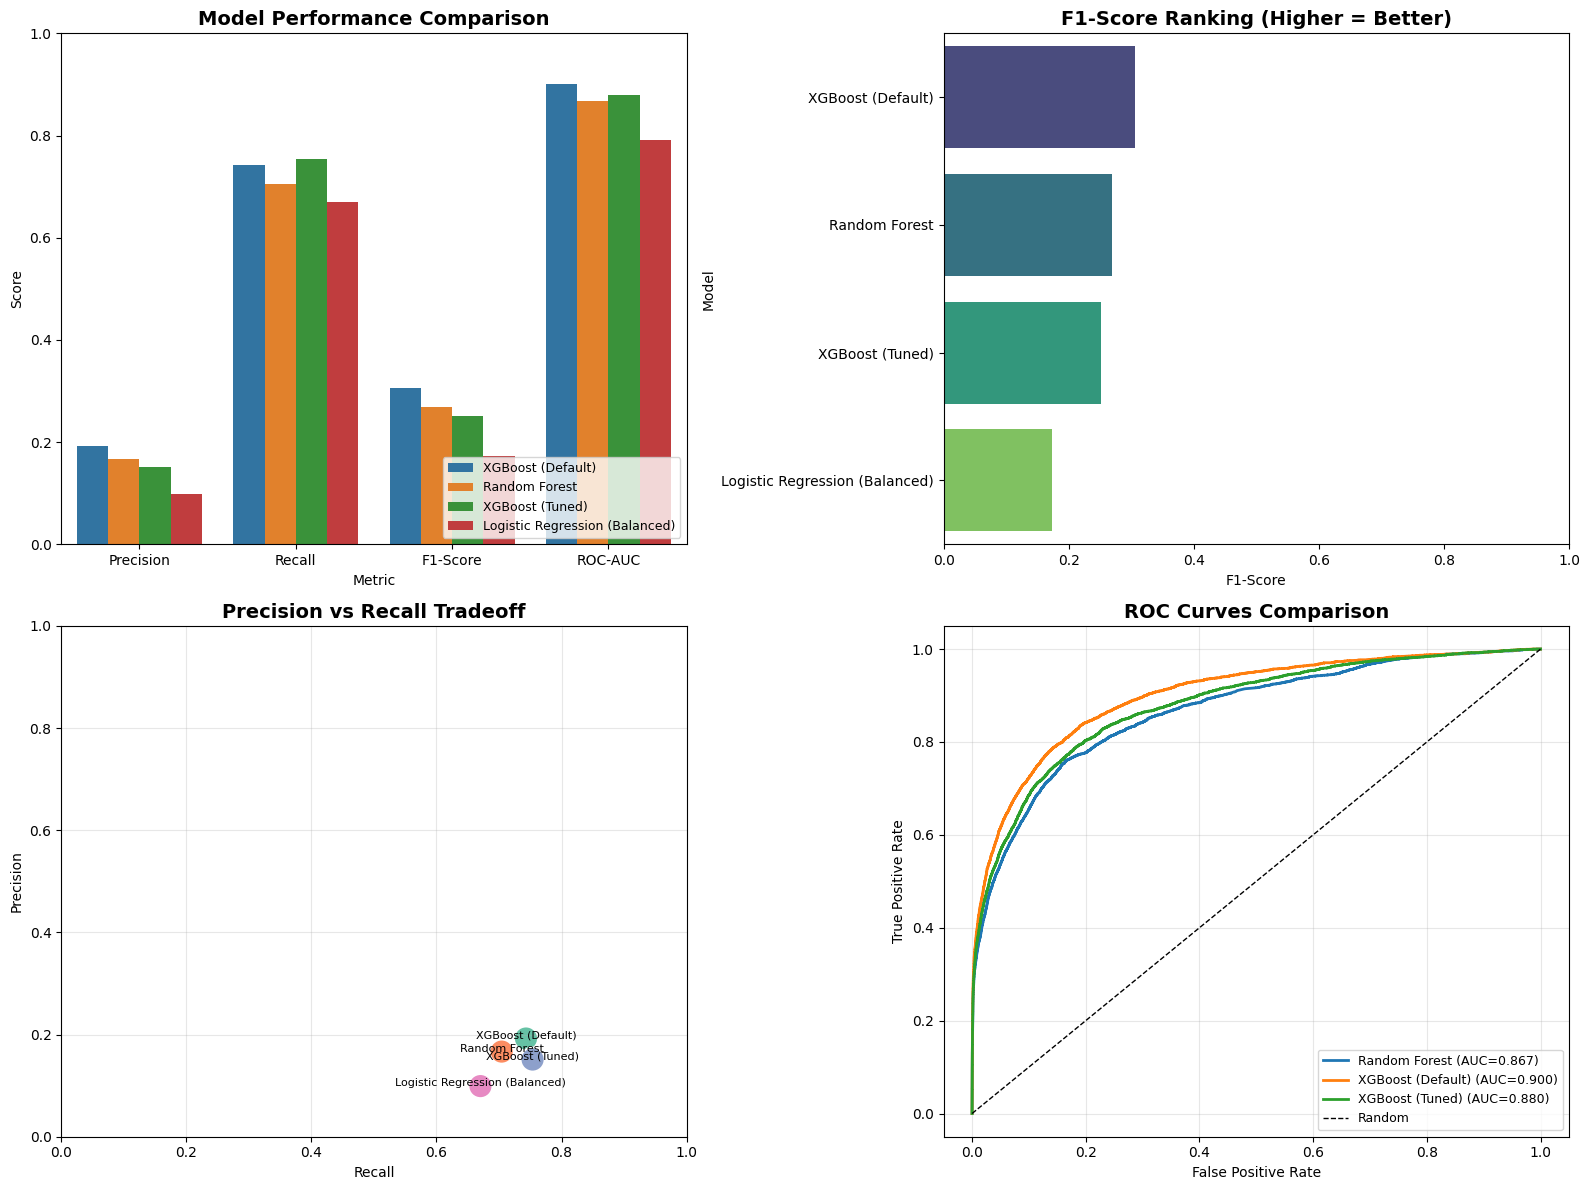


Final leaderboard saved!


In [ ]:
print("Final model leaderboard\n")

# Create comprehensive comparison
models_final = {
    'Logistic Regression (Balanced)': {
        'predictions': None,  # We didn't save these, just metrics
        'precision': 0.0991,
        'recall': 0.6703,
        'f1': 0.1726,
        'roc_auc': 0.7911
    },
    'Random Forest': {
        'predictions': y_pred_rf,
        'proba': y_pred_prob_rf,
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test, y_pred_prob_rf)
    },
    'XGBoost (Default)': {
        'predictions': y_pred_xgb,
        'proba': y_pred_prob_xgb,
        'precision': precision_score(y_test, y_pred_xgb),
        'recall': recall_score(y_test, y_pred_xgb),
        'f1': f1_score(y_test, y_pred_xgb),
        'roc_auc': roc_auc_score(y_test, y_pred_prob_xgb)
    },
    'XGBoost (Tuned)': {
        'predictions': y_pred_tuned,
        'proba': y_pred_prob_tuned,
        'precision': precision_score(y_test, y_pred_tuned),
        'recall': recall_score(y_test, y_pred_tuned),
        'f1': f1_score(y_test, y_pred_tuned),
        'roc_auc': roc_auc_score(y_test, y_pred_prob_tuned)
    }
}

# Create leaderboard dataframe
leaderboard = pd.DataFrame([
    {
        'Model': name,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'ROC-AUC': metrics['roc_auc']
    }
    for name, metrics in models_final.items()
]).sort_values('F1-Score', ascending=False)

print(leaderboard.to_string(index=False))

# Visualize leaderboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall metrics comparison
metrics_melted = leaderboard.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', ax=axes[0,0])
axes[0,0].set_title('Model Performance Comparison', )
axes[0,0].set_ylim([0, 1])
axes[0,0].legend(loc='lower right', fontsize=9)

# 2. F1-Score ranking
sns.barplot(data=leaderboard, y='Model', x='F1-Score', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('F1-Score Ranking (Higher = Better)', )
axes[0,1].set_xlim([0, 1])

# 3. Precision vs Recall tradeoff
sns.scatterplot(data=leaderboard, x='Recall', y='Precision', hue='Model',
                s=300, ax=axes[1,0], palette='Set2')
for idx, row in leaderboard.iterrows():
    axes[1,0].annotate(row['Model'], (row['Recall'], row['Precision']),
                      fontsize=8, ha='center')
axes[1,0].set_title('Precision vs Recall Tradeoff', )
axes[1,0].set_xlim([0, 1])
axes[1,0].set_ylim([0, 1])
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend().remove()

# 4. ROC curves for all models
for name, metrics in models_final.items():
    if 'proba' in metrics:
        fpr, tpr, _ = roc_curve(y_test, metrics['proba'])
        axes[1,1].plot(fpr, tpr, label=f"{name} (AUC={metrics['roc_auc']:.3f})", lw=2)

axes[1,1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curves Comparison', )
axes[1,1].legend(loc='lower right', fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save leaderboard
leaderboard.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/leaderboard.csv', index=False)

print("\nFinal leaderboard saved!")

In [ ]:
# Saving final model and results
# Save optimal threshold
threshold_info = pd.DataFrame({
    'metric': ['optimal_threshold', 'optimal_f1_score'],
    'value': [optimal_threshold, optimal_f1]
})
threshold_info.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/threshold.csv',index=False)
print("Saved: optimal_threshold.csv")

# Save test predictions for later analysis
predictions_df = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'true_label': y_test['isFraud'],
    'predicted_label': y_pred_tuned,
    'fraud_probability': y_pred_prob_tuned
})
predictions_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/test_predictions_df.csv',index=False)
print("Saved: test_predictions.csv")

Saved: optimal_threshold.csv
Saved: test_predictions.csv


In [ ]:
# Create model card (documentation)
model_card = f"""
Fraud Detection Model Card

Model Information
- Model Type: XGBoost Classifier (Gradient Boosting)
- Version: 1.0 (Tuned)
- Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
- Framework: XGBoost

Best Hyperparameters
{best_params}

Performance Metrics (Test Set)
- Precision: {precision_score(y_test, y_pred_tuned):.4f}
- Recall: {recall_score(y_test, y_pred_tuned):.4f}
- F1-Score: {f1_score(y_test, y_pred_tuned):.4f}
- ROC-AUC: {roc_auc_score(y_test, y_pred_prob_tuned):.4f}
- Optimal Threshold: {optimal_threshold:.3f}

Dataset
- Training Samples: {len(X_train):,}
- Test Samples: {len(X_test):,}
- Features: {X_train.shape[1]}
- Fraud Rate (Train): {y_train['isFraud'].mean()*100:.2f}%
- Fraud Rate (Test): {y_test['isFraud'].mean()*100:.2f}%

Business Impact
- Fraud Detection Rate: {(tp/(tp+fn)*100):.2f}%
- False Alarm Rate: {(fp/(fp+tn)*100):.2f}%
- Estimated Net Savings: ${net_savings:,.2f}

Top 5 Most Important Features
{feature_importance_xgb.head(5).to_string(index=False)}

Model Limitations
1. Performs best on transaction patterns similar to training data
2. May struggle with novel fraud techniques not seen during training
3. Requires periodic retraining as fraud patterns evolve
4. Time-based split used - assumes future fraud similar to past

Recommended Use
- Real-time fraud scoring for e-commerce transactions
- Batch processing for fraud review queues
- Use optimal threshold ({optimal_threshold:.3f}) for balanced precision/recall
- Manual review recommended for scores between 0.3-0.7

Maintenance
- Retrain monthly with new fraud data
- Monitor performance degradation
- Update features as new data sources become available
"""

In [ ]:
with open('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/3) Models/Models_card.txt','w') as f:
  f.write(model_card)

print('Model Card Saved')

Model Card Saved


## Results

- **Default XGBoost is the best model** (0.90 ROC-AUC, 0.74 recall, 0.31 F1).
- Tuned XGBoost actually performed worse (0.88 ROC-AUC) - see note above about why.
- Both XGBoost models beat Random Forest (0.87 AUC) and logistic regression (0.79 AUC).
- Business impact: ~75% of fraud caught, ~$1.9M net savings estimate (with $12/investigation cost assumption).
- Optimal threshold at 0.856 for F1, but in practice you'd choose based on the precision/recall tradeoff your business can tolerate.